# Dataset Analysis & Preprocessing
### Purpose

- Understand and prepare the dataset before modeling.

### Import Necessary Libraries


In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Create Required Folders 

# Root Path
ROOT = Path().resolve().parent

# Add src path folder for import
sys.path.append(str(ROOT / "src"))

# Create root directories
models_dir = ROOT / "weights"    # For models
models_dir.mkdir(exist_ok=True)

datasets_dir = ROOT / "data"     # For datasets
datasets_dir.mkdir(exist_ok=True)


results_dir = ROOT / "results"
results_dir.mkdir(exist_ok=True)

# 1. Load the Dataset

The M‑ABSA dataset is a large multilingual resource for Aspect‑Based Sentiment Analysis (ABSA).

It covers 21 languages and 7 domains, designed to support fine‑grained sentiment tasks such as extracting aspect terms, categories, and sentiment polarities

In [3]:
# Load dataset
dataset = load_dataset("Multilingual-NLP/M-ABSA")

print(dataset)
print(dataset.column_names)


DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 184716
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 45906
    })
    test: Dataset({
        features: ['text'],
        num_rows: 79674
    })
})
{'train': ['text'], 'validation': ['text'], 'test': ['text']}


# 2. Basic Dataset Info:
###  Structure of the Dataset
Each entry in the dataset typically contains:
- Text: A sentence or review in one of the supported languages.
- Triplet Labels: [aspect term, aspect category, sentiment polarity].
- Delimiter: Sentences and triplets are separated by "####".


Example:
Text: “The laptop battery life is disappointing.”
Triplet: [battery life, hardware quality, negative].

In [2]:

# Sample Train set
print(dataset["train"][10])


# Check a few samples to understand the structure
for i in range(1, 10000, 2000):

    text, triplets = dataset["train"][i]["text"].split("####")
    print("\nSentence:", text)
    print("Triplets:", triplets)
    print()
    
    

{'text': "\u200eلقدكانتهذهدورةرائعة.####[['دورة', 'course general', 'positive']]"}

Sentence: ‎وأخيرًا، مقدمة قصيرة عن فن استخدام أحكام القضاء كحدث أو اختبار، على سبيل المثال؛ في "ميراندا"، أو "كيلر"، أو "براون"، أو "اختبار ماكدونيل دوغلاس".
Triplets: []


Sentence: Han får mig også til at grine i hver video.
Triplets: [['NULL', 'faculty general', 'positive']]


Sentence: Anyway , the course teach me how to learn in a better way , I will introduce it to my students .
Triplets: []


Sentence: Si consulta sitios de preguntas y respuestas en Internet, probablemente encontrará que este es el inicio curso más recomendado para ramas relacionadas de la ciencia y la ingeniería.
Triplets: [['curso', 'course general', 'positive']]


Sentence: और, व्याख्याता श्री टिम रफगार्डन ने वह सार प्रस्तुत किया जिसकी मुझे आवश्यकता थी।
Triplets: [['श्री टिम रफगार्डन', 'faculty general', 'positive']]



# 3. Text Preprocessing.

Steps:
- Iterate through each example in the split.
- Ensure the text contains the delimiter '####' separating sentence and triplets.
- Skip examples with empty triplets.
- Keep only sentences written in Korean.
- Parse triplets and store them in a structured DataFrame.

In [5]:
from data_processing.process_dataset import *  # Functions for preprocessing 

# Process all splits and combine into one DataFrame
train_df = process_split("train", dataset)
val_df = process_split("validation", dataset)
test_df = process_split("test", dataset)

full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Print summary
print("Number of Korean aspect samples:", len(full_df))

Number of Korean aspect samples: 20967


In [ ]:

print("\nTop Categories:")
print(full_df["category"].value_counts())

print("\nSentiment Distribution:")
print(full_df["sentiment"].value_counts())



Number of Korean aspect samples: 20967

Top Categories:
category
food quality                    1791
service general                 1099
food general                    1040
course general                   912
Overall#Overall                  908
                                ... 
material workload                  1
MOUSE#USABILITY                    1
Out_Of_Scope#DESIGN_FEATURES       1
KEYBOARD#MISCELLANEOUS             1
OS#QUALITY                         1
Name: count, Length: 279, dtype: int64

Sentiment Distribution:
sentiment
positive    13533
negative     4084
POS          1301
neutral       833
NEU           832
NEG           370
conflict        5
Neg             4
Neu             3
NEU             2
Name: count, dtype: int64


### Mapping Aspects for Restaurant Reviews

In [ ]:
# Mapping aspects
aspect_mapping = {
    "food quality": "FOOD",
    "food_drinks quality": "FOOD",
    "food general": "FOOD",
    "food recommendation": "FOOD",
    "drinks quality": "FOOD",

    "food prices": "PRICE",
    "restaurant prices": "PRICE",
    "food_drinks prices": "PRICE",
    "drinks prices": "PRICE",

    "service general": "SERVICE",

    "ambience general": "AMBIENCE",
    "location general": "AMBIENCE"
}

restaurant_df = full_df[
    full_df["category"].isin(aspect_mapping.keys())
].copy()

restaurant_df["aspect"] = restaurant_df["category"].map(aspect_mapping)
print(restaurant_df["aspect"].value_counts())
print(restaurant_df["sentiment"].value_counts())


aspect
FOOD        3100
SERVICE     1099
AMBIENCE     806
PRICE        319
Name: count, dtype: int64
sentiment
positive    4007
negative    1074
neutral      242
conflict       1
Name: count, dtype: int64


### Build Labels
- 0 = Aspect not mentioned
- 1 = Aspect mentioned with Negative sentiment
- 2 = Aspect mentioned with Positive sentiment

In [ ]:
from data_processing.build_labels import build_labels  # Label building function

# Define the aspects of interest for restaurant reviews
aspects = ["FOOD", "PRICE", "SERVICE", "AMBIENCE"]
    

# Group by sentence and apply labeling function
multi_class_df = (
    restaurant_df.groupby("sentence")
    .apply(build_labels)
    .reset_index()
)

# Print dataset size
print("Final dataset size:", len(multi_class_df))

# Show distribution of labels for each aspect
for aspect in aspects:
    print(multi_class_df[aspect].value_counts())
    print()


# Clean up sentence text
multi_class_df["sentence"] = (
    multi_class_df["sentence"]
    .astype(str)  # ensure all values are strings
    .str.strip()  # remove leading/trailing whitespace
    .str.replace(r'^[\s\-–—•·\.\"]+', '', regex=True)  # remove leading junk characters
    .str.replace(r'\s+', ' ', regex=True)  # normalize multiple spaces
    .str.strip()  # final trim
)


Final dataset size: 3718
FOOD
2    1853
0    1433
1     432
Name: count, dtype: int64

PRICE
0    3435
2     150
1     133
Name: count, dtype: int64

SERVICE
0    2853
2     568
1     297
Name: count, dtype: int64

AMBIENCE
0    3087
2     573
1      58
Name: count, dtype: int64

Saved: multi_class_df_to_edit.csv


### Concatenate with manual datasets

In [ ]:
# Load manually created samples to address extreme class imbalance
manual_sample = pd.read_csv(ROOT / "data" / "manual_samples.csv", encoding="utf-8-sig")
print(manual_sample.shape)


# Ensure manual samples contain valid numeric labels for all aspects
for col in aspects:
    manual_sample = manual_sample[pd.to_numeric(manual_sample[col], errors="coerce").notnull()]

# Convert aspect labels to integers (0, 1, 2)
manual_sample[aspects] = manual_sample[aspects].astype(int)

# Concatenate original dataset with manual samples
df = pd.concat([multi_class_df, manual_sample], ignore_index=True)

# Remove duplicate sentences
df = df.drop_duplicates(subset=["sentence"]).reset_index(drop=True)

# Save the final combined dataset
df.to_csv(ROOT / "data" / "multi_class_df.csv", index=False, encoding="utf-8-sig")
print(df.shape)


## Load the processed final dataset

In [3]:
# Load the Dataset
df = pd.read_csv(ROOT / "data" / "multi_class_df.csv",  encoding="utf-8-sig")

# Print Information of the dataset
print("The shape of the dataset :", df.shape)
print("\nThe first five rows of the dataset: \n", df.head())
print("\nThe info of the dataset :")
print(df.info())
print()
print("Total number of missing values in each column:")
print(df.isnull().sum())


The shape of the dataset : (3641, 5)

The first five rows of the dataset: 
                                             sentence  FOOD  PRICE  SERVICE  \
0         수프는 치즈와 국수를 섞은 요리인데, 맛이 이상해서 별로 먹고 싶지 않아요.     1      0        0   
1                                       만큼의 가치가 있어요.     0      2        0   
2  '유기농'이란 말이 '흙 맛'을 뜻한다고 생각한다면, 이것들민트은 당신에게 딱 맞습니다.     2      0        0   
3                ( 아스파라거스, 트러플 오일, 파마산 브루스케타가 최고예요!)     2      0        0   
4                        ( 항상 바텐더에게 계절 맥주를 요청하세요 !!!     2      0        0   

   AMBIENCE  
0         0  
1         0  
2         0  
3         0  
4         0  

The info of the dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3641 entries, 0 to 3640
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  3641 non-null   object
 1   FOOD      3641 non-null   int64 
 2   PRICE     3641 non-null   int64 
 3   SERVICE   3641 non-null   int64 
 4   AMBIE

# 4. Dataset Visualization

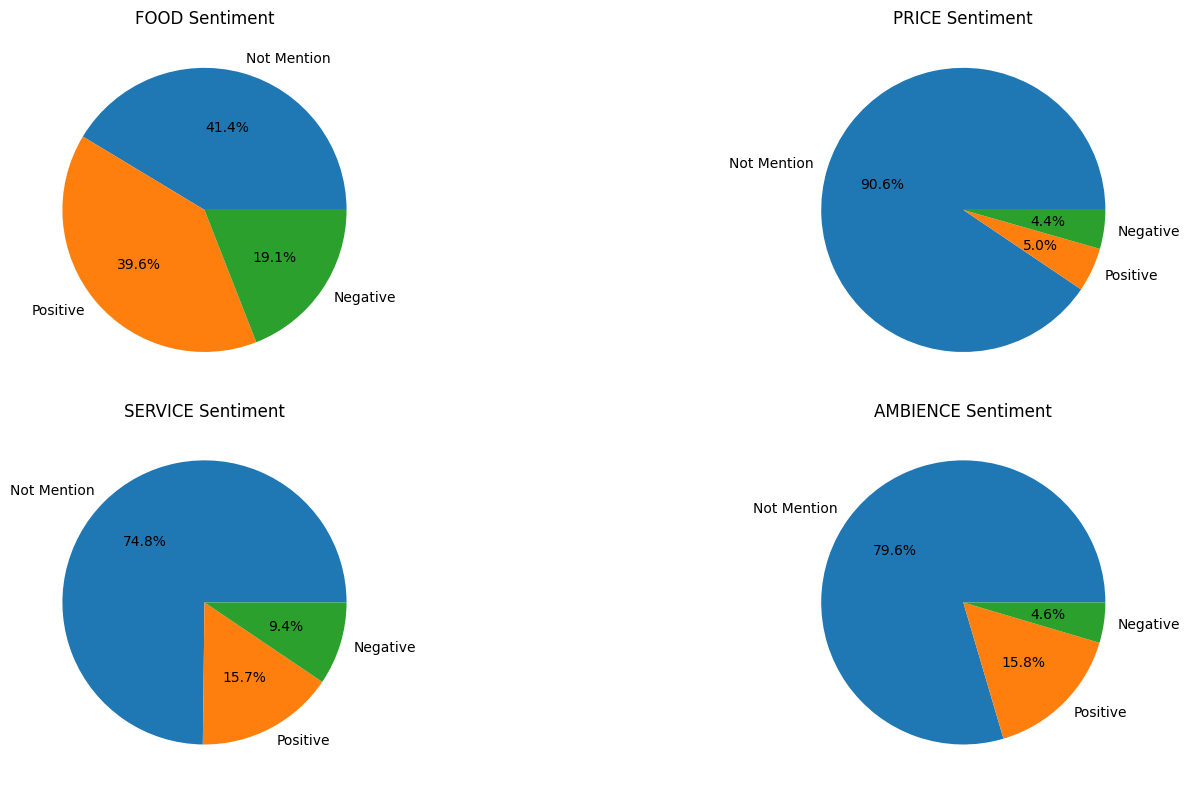

In [6]:
# Distribution of Dataset
plt.figure(figsize=(18, 8))

aspects = ["FOOD", "PRICE", "SERVICE", "AMBIENCE"]
for i, aspect in enumerate(aspects):
    counts = df[aspect].value_counts()
    labels = counts.index.map({0:"Not Mention", 1:"Negative", 2:"Positive"})
    # Plot the piechart
    plt.subplot(2, 2, i+1)
    plt.pie(counts, labels=labels, autopct='%1.1f%%')
    plt.title(f'{aspect} Sentiment')
    
plt.tight_layout()    
plt.show()

### Sentiment Distribution Per Aspect

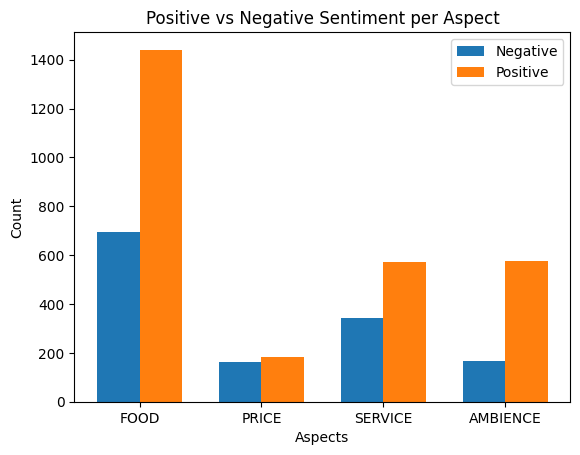

In [10]:
# Positive and Negative Sentiment distribution
def plot_sentiment_bar(df, aspects):
    positive_counts = []
    negative_counts = []

    for aspect in aspects:
        positive_counts.append((df[aspect] == 2).sum())
        negative_counts.append((df[aspect] == 1).sum())

    x = range(len(aspects))
    width = 0.35

    plt.figure()
    plt.bar(x, negative_counts, width=width)
    plt.bar([i + width for i in x], positive_counts, width=width)

    plt.xticks([i + width / 2 for i in x], aspects)
    plt.xlabel("Aspects")
    plt.ylabel("Count")
    plt.title("Positive vs Negative Sentiment per Aspect")
    plt.legend(["Negative", "Positive"])

    plt.show()
    
plot_sentiment_bar(df, aspects)

### Co-occurance Matrix 
- How often different aspects appear together within the same review or sentence

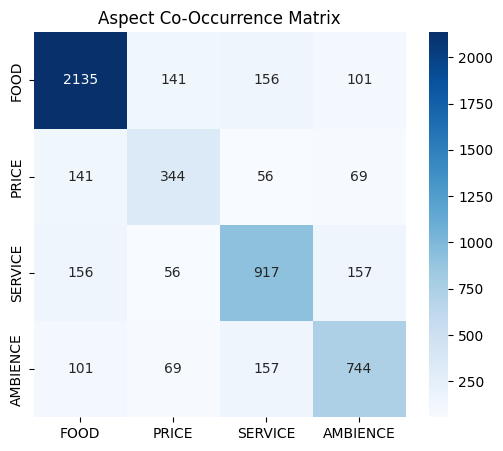

In [11]:

import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert to mention matrix
# -------------------------
# Each cell in 'mention' is 1 if the aspect is present in the review, else 0.
mention = (df[aspects] > 0).astype(int)

# Step 2: Compute co-occurrence matrix
# -------------------------
# Dot product of mention.T and mention gives counts of how often
# aspects co-occur across reviews.
co_matrix = mention.T.dot(mention)

# Plot heatmap
plt.figure(figsize=(6,5))


sns.heatmap(
    co_matrix,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Aspect Co-Occurrence Matrix")
plt.show()

### Multi-Aspect Sentence Distribution
- How many different aspects are mentioned within individual sentence or review.
- Most reviews mention only 1 aspect
- Some reviews mention 2 aspects
- Very few discuss all 4 aspects 

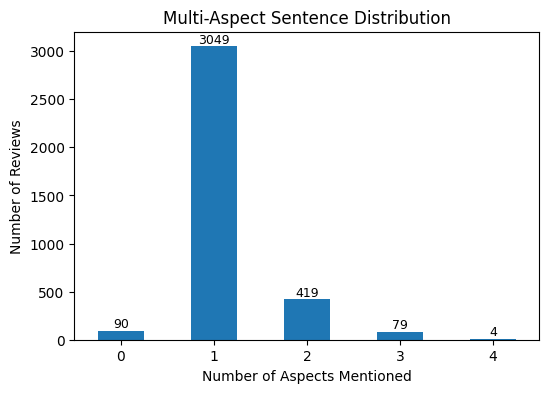

In [12]:
# Count how many aspects are mentioned per review
aspect_count = mention.sum(axis=1)

# Get distribution of counts (how many reviews mention 1, 2, 3... aspects)
dist = aspect_count.value_counts().sort_index()

# Create figure
plt.figure(figsize=(6,4))

# Plot distribution as a bar chart
ax = dist.plot(kind="bar")

# Label axes and title
plt.xlabel("Number of Aspects Mentioned")
plt.ylabel("Number of Reviews")
plt.title("Multi-Aspect Sentence Distribution")

# Keep x-axis labels horizontal
plt.xticks(rotation=0)

# -------------------------
# Add counts above each bar
# -------------------------
for i, value in enumerate(dist):
    ax.text(i, value + 5, str(value), ha="center", va="bottom", fontsize=9)

# Show plot
plt.show()


### Split the dataset

In [7]:
from data_processing.multilabel_split import split_data

X = df["sentence"]
y = df[aspects]

X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y, aspects)
    
print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))




Train: 2548
Val: 546
Test: 547


In [8]:
# Label Distribution

def print_label_distribution(y_split, name):
    print(f"\n{name} Distribution (n={len(y_split)})")
    print("-" * 40)
    for asp in aspects:
        counts = y_split[asp].value_counts().sort_index()
        props  = y_split[asp].value_counts(normalize=True).sort_index()
        summary = pd.DataFrame({"count": counts, "pct(%)": props.mul(100).round(1)})
        print(f"{asp}:\n{summary}\n")

print_label_distribution(y_train, "TRAIN")
print_label_distribution(y_val, "VALIDATION")
print_label_distribution(y_test, "TEST")



TRAIN Distribution (n=2548)
----------------------------------------
FOOD:
      count  pct(%)
FOOD               
0      1054    41.4
1       484    19.0
2      1010    39.6

PRICE:
       count  pct(%)
PRICE               
0       2307    90.5
1        109     4.3
2        132     5.2

SERVICE:
         count  pct(%)
SERVICE               
0         1906    74.8
1          251     9.9
2          391    15.3

AMBIENCE:
          count  pct(%)
AMBIENCE               
0          2027    79.6
1           123     4.8
2           398    15.6


VALIDATION Distribution (n=546)
----------------------------------------
FOOD:
      count  pct(%)
FOOD               
0       226    41.4
1        91    16.7
2       229    41.9

PRICE:
       count  pct(%)
PRICE               
0        495    90.7
1         28     5.1
2         23     4.2

SERVICE:
         count  pct(%)
SERVICE               
0          409    74.9
1           41     7.5
2           96    17.6

AMBIENCE:
          count  pct(%)
A